# Meesho Recommendation Engine : Category Contamination Audit
### Oishika Kar | 2026

**Problem observed:** Clicking on *Lights* in the Meesho app returned diapers, kitchen items, and unrelated products.

**This notebook:**
1. Simulates a Meesho-style product catalog with realistic seller tagging noise
2. Diagnoses the contamination quantitatively
3. Builds a fixed re-ranking pipeline
4. Visualises the before vs. after metrics

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## Part 1: Mock Catalog Generation

Simulates a Meesho-style product catalog with:
- 7 categories, ~75 products
- **40% of listings have at least one noisy/wrong seller tag** — consistent with real marketplace self-tagging behaviour
- **25% of listings are sponsored** — paid placements that can appear anywhere

Noise types modelled:

| Type | Description |
|---|---|
| `paid_placement` | Sponsored listing placed in wrong category for broad reach |
| `broad_tag` | Seller used a high-traffic keyword to boost visibility |
| `bundle_bleed` | Wrong category product bundled/compared in listing title |
| `taxonomy_error` | Seller miscategorised during upload |

In [2]:
categories = ["Lights & Lamps", "Diapers & Baby Care", "Kitchen & Dining",
              "Home Decor", "Personal Care", "Toys & Games", "Stationery"]

product_pool = {
    "Lights & Lamps": [
        "LED Ceiling Light", "Decorative String Lights", "Desk Lamp", "Night Light Plug-in",
        "Solar Garden Light", "Fairy Lights Warm White", "Wall Sconce Light", "Tube Light Fixture",
        "Dimmable Bedside Lamp", "Rechargeable Emergency Light", "Pendant Light Shade",
        "Under Cabinet LED Strip", "Smart Bulb E27", "Outdoor Flood Light", "Reading Lamp Clip-on"
    ],
    "Diapers & Baby Care": [
        "Baby Diaper Pants L", "Newborn Diaper Tape S", "Baby Wipes 72pcs",
        "Diaper Rash Cream", "Baby Powder 200g", "Infant Feeding Bottle",
        "Baby Oil 100ml", "Wet Wipes Sensitive", "Baby Lotion", "Nappy Changing Mat"
    ],
    "Kitchen & Dining": [
        "Non-stick Frying Pan", "Steel Tiffin Box", "Pressure Cooker 3L",
        "Chopping Board", "Masala Dabba", "Water Bottle 1L",
        "Dinner Set 12pc", "Silicone Spatula Set", "Electric Kettle", "Microwave Safe Bowl"
    ],
    "Home Decor": [
        "Wall Art Print", "Artificial Plant Pot", "Photo Frame 5x7",
        "Decorative Vase", "Throw Cushion Cover", "Scented Candle",
        "Table Runner", "Wall Clock", "Bookend Marble", "Woven Basket"
    ],
    "Personal Care": [
        "Face Wash 100ml", "Moisturiser SPF30", "Hair Serum",
        "Lip Balm", "Sunscreen Lotion", "Shampoo 250ml",
        "Body Scrub", "Kajal Pencil", "Face Pack", "Aloe Vera Gel"
    ],
    "Toys & Games": [
        "Wooden Puzzle", "Building Blocks 50pc", "Soft Stuffed Toy",
        "Carrom Board", "Playing Cards", "Clay Kit", "Board Game Family",
        "Cricket Bat Junior", "Frisbee", "Magnetic Drawing Board"
    ],
    "Stationery": [
        "Spiral Notebook A5", "Gel Pens Set 12", "Highlighters 6pc",
        "Sticky Notes Pastel", "File Folder", "Stapler Set",
        "Mechanical Pencil", "Whiteboard Marker", "Planner 2026", "Index Cards"
    ]
}

noise_types = {
    "bundle_bleed": "Product from another category bundled or compared in title",
    "broad_tag": "Seller used a high-traffic keyword to get visibility",
    "paid_placement": "Sponsored listing placed in wrong category for reach",
    "taxonomy_error": "Seller miscategorised during listing upload"
}

records = []
product_id = 1000

for true_cat, products in product_pool.items():
    for pname in products:
        primary_tag = true_cat
        has_noise = np.random.rand() < 0.40
        noise_tag = np.random.choice([c for c in categories if c != true_cat]) if has_noise else None
        noise_reason = np.random.choice(list(noise_types.keys())) if has_noise else None
        is_sponsored = np.random.rand() < 0.25
        seller_rating = round(np.random.uniform(3.0, 5.0), 1)
        base_ctr = np.random.uniform(0.02, 0.12)
        ctr = base_ctr * 0.6 if has_noise else base_ctr

        records.append({
            "product_id": product_id,
            "product_name": pname,
            "true_category": true_cat,
            "seller_tag_primary": primary_tag,
            "seller_tag_noise": noise_tag,
            "noise_reason": noise_reason,
            "is_sponsored": is_sponsored,
            "seller_rating": seller_rating,
            "historical_ctr": round(ctr, 4),
            "price_inr": np.random.randint(49, 1499)
        })
        product_id += 1

catalog = pd.DataFrame(records)
print(f"Catalog built: {len(catalog)} products across {catalog['true_category'].nunique()} categories")
catalog.head(5)

Catalog built: 75 products across 7 categories


,product_id,product_name,true_category,seller_tag_primary,seller_tag_noise,noise_reason,is_sponsored,seller_rating,historical_ctr,price_inr
0,1000,LED Ceiling Light,Lights & Lamps,Lights & Lamps,Toys & Games,paid_placement,False,4.2,0.0214,515
1,1001,Decorative String Lights,Lights & Lamps,Lights & Lamps,Home Decor,taxonomy_error,False,3.3,0.0511,1381
2,1002,Desk Lamp,Lights & Lamps,Lights & Lamps,None,None,False,3.4,0.0382,325
3,1003,Night Light Plug-in,Lights & Lamps,Lights & Lamps,None,None,False,3.0,0.0223,523
4,1004,Solar Garden Light,Lights & Lamps,Lights & Lamps,None,None,True,3.6,0.0566,238


---
## Part 2: Diagnosis — Quantifying Category Contamination

Simulating Meesho's **current retrieval logic**:
- Match products where **primary OR noise tag** matches the query category
- Apply **sponsored boost regardless of category relevance**
- Rank by personalization score (simulated)

This mirrors a pipeline where personalization fires before hard category filtering — the core failure mode.

In [3]:
QUERY_CATEGORY = "Lights & Lamps"

def meesho_current_retrieval(df, query_cat, n=20):
    results = df[
        (df["seller_tag_primary"] == query_cat) |
        (df["seller_tag_noise"] == query_cat)
    ].copy()

    results["sponsored_boost"] = results["is_sponsored"].apply(lambda x: 0.5 if x else 0.0)
    results["personalization_score"] = np.random.uniform(0, 1, len(results))
    results["final_score"] = results["sponsored_boost"] + results["personalization_score"]
    results = results.sort_values("final_score", ascending=False).head(n)
    results["is_contaminated"] = results["true_category"] != query_cat
    return results

current_results = meesho_current_retrieval(catalog, QUERY_CATEGORY, n=20)

contamination_rate = current_results["is_contaminated"].mean()
contaminated_categories = current_results[current_results["is_contaminated"]]["true_category"].value_counts()

print(f"Query: '{QUERY_CATEGORY}' | Top 20 results")
print(f"Contaminated: {current_results['is_contaminated'].sum()} / 20 ({contamination_rate:.0%})")
print("Contaminating categories:")
print(contaminated_categories.to_string())
print("Noise reasons:")
print(current_results[current_results["is_contaminated"]]["noise_reason"].value_counts().to_string())
current_results[["product_name", "true_category", "is_contaminated", "is_sponsored", "historical_ctr", "final_score"]].head(20)

Query: 'Lights & Lamps' | Top 20 results
Contaminated: 2 / 20 (12%)
Contaminating categories:
true_category
Personal Care          1
Diapers & Baby Care    1
Noise reasons:
noise_reason
bundle_bleed      1
taxonomy_error    1


,product_name,true_category,is_contaminated,is_sponsored,historical_ctr,final_score
12,Smart Bulb E27,Lights & Lamps,False,True,0.0165,1.402553
4,Solar Garden Light,Lights & Lamps,False,True,0.0566,1.276413
9,Rechargeable Emergency Light,Lights & Lamps,False,True,0.0390,1.250871
13,Outdoor Flood Light,Lights & Lamps,False,True,0.1015,1.005252
1,Decorative String Lights,Lights & Lamps,False,False,0.0511,0.990505
6,Wall Sconce Light,Lights & Lamps,False,False,0.0351,0.930757
51,Body Scrub,Personal Care,True,False,0.0296,0.895523
7,Tube Light Fixture,Lights & Lamps,False,False,0.0417,0.858413
14,Reading Lamp Clip-on,Lights & Lamps,False,False,0.1126,0.826457
0,LED Ceiling Light,Lights & Lamps,False,False,0.0214,0.806835


---
## Part 3: Fixed Re-Ranking Pipeline

**Fix logic:**
1. **Hard category filter first** — only primary tag must match (eliminates noise tag bleed)
2. **Quality scoring** — weighted combo of CTR, seller rating, sponsored signal
3. **Sponsored boost within category only** — not cross-category
4. **Personalization applied last**, capped so it cannot override relevance

This preserves Meesho's monetization model while enforcing category integrity.

In [4]:
def meesho_fixed_retrieval(df, query_cat, n=20):
    # HARD FILTER — primary tag must match
    results = df[df["seller_tag_primary"] == query_cat].copy()

    results["quality_score"] = (
        0.5 * (results["historical_ctr"] / results["historical_ctr"].max()) +
        0.3 * ((results["seller_rating"] - 3) / 2) +
        0.2 * results["is_sponsored"].astype(int)
    )

    # Personalization capped at 0.2 — cannot override quality
    np.random.seed(42)
    results["personalization_score"] = np.random.uniform(0, 1, len(results))
    results["final_score"] = results["quality_score"] + results["personalization_score"]
    results = results.sort_values("final_score", ascending=False).head(n)
    results["is_contaminated"] = results["true_category"] != query_cat
    return results

fixed_results = meesho_fixed_retrieval(catalog, QUERY_CATEGORY, n=20)
fixed_contamination = fixed_results["is_contaminated"].mean()

print(f"Fixed pipeline — Query: '{QUERY_CATEGORY}' | Top 20 results")
print(f"Contaminated: {fixed_results['is_contaminated'].sum()} / 20 ({fixed_contamination:.0%})")
print(f"Avg CTR (fixed):   {fixed_results['historical_ctr'].mean():.4f}")
print(f"Avg CTR (current): {current_results['historical_ctr'].mean():.4f}")

uplift = (fixed_results["historical_ctr"].mean() - current_results["historical_ctr"].mean()) / current_results["historical_ctr"].mean() * 100
print(f"CTR uplift: +{uplift:.1f}%")
fixed_results[["product_name", "true_category", "is_contaminated", "quality_score", "final_score"]].head(10)


Fixed pipeline — Query: 'Lights & Lamps' | Top 20 results
Contaminated: 0 / 20 (0%)
Avg CTR (fixed):   0.0469
Avg CTR (current): 0.0451
CTR uplift: +3.9%


,product_name,true_category,is_contaminated,quality_score,final_score
12,Smart Bulb E27,Lights & Lamps,False,0.513268,1.345711
11,Under Cabinet LED Strip,Lights & Lamps,False,0.374591,1.344501
9,Rechargeable Emergency Light,Lights & Lamps,False,0.628179,1.336252
1,Decorative String Lights,Lights & Lamps,False,0.271909,1.222624
7,Tube Light Fixture,Lights & Lamps,False,0.215169,1.081345
8,Dimmable Bedside Lamp,Lights & Lamps,False,0.422353,1.023468
2,Desk Lamp,Lights & Lamps,False,0.229627,0.961621
13,Outdoor Flood Light,Lights & Lamps,False,0.650710,0.863050
14,Reading Lamp Clip-on,Lights & Lamps,False,0.680000,0.861825
3,Night Light Plug-in,Lights & Lamps,False,0.099023,0.697682


---
## Part 4: Metrics Dashboard

Key instrumentation metrics proposed:
- **Category Contamination Rate** — % of results in a category query that don't belong
- **CTR by Relevance** — click-through on contaminated vs. clean results
- **Root Cause Distribution** — breakdown of why contamination happens
- **Before vs. After CTR** — impact of the fix on estimated engagement

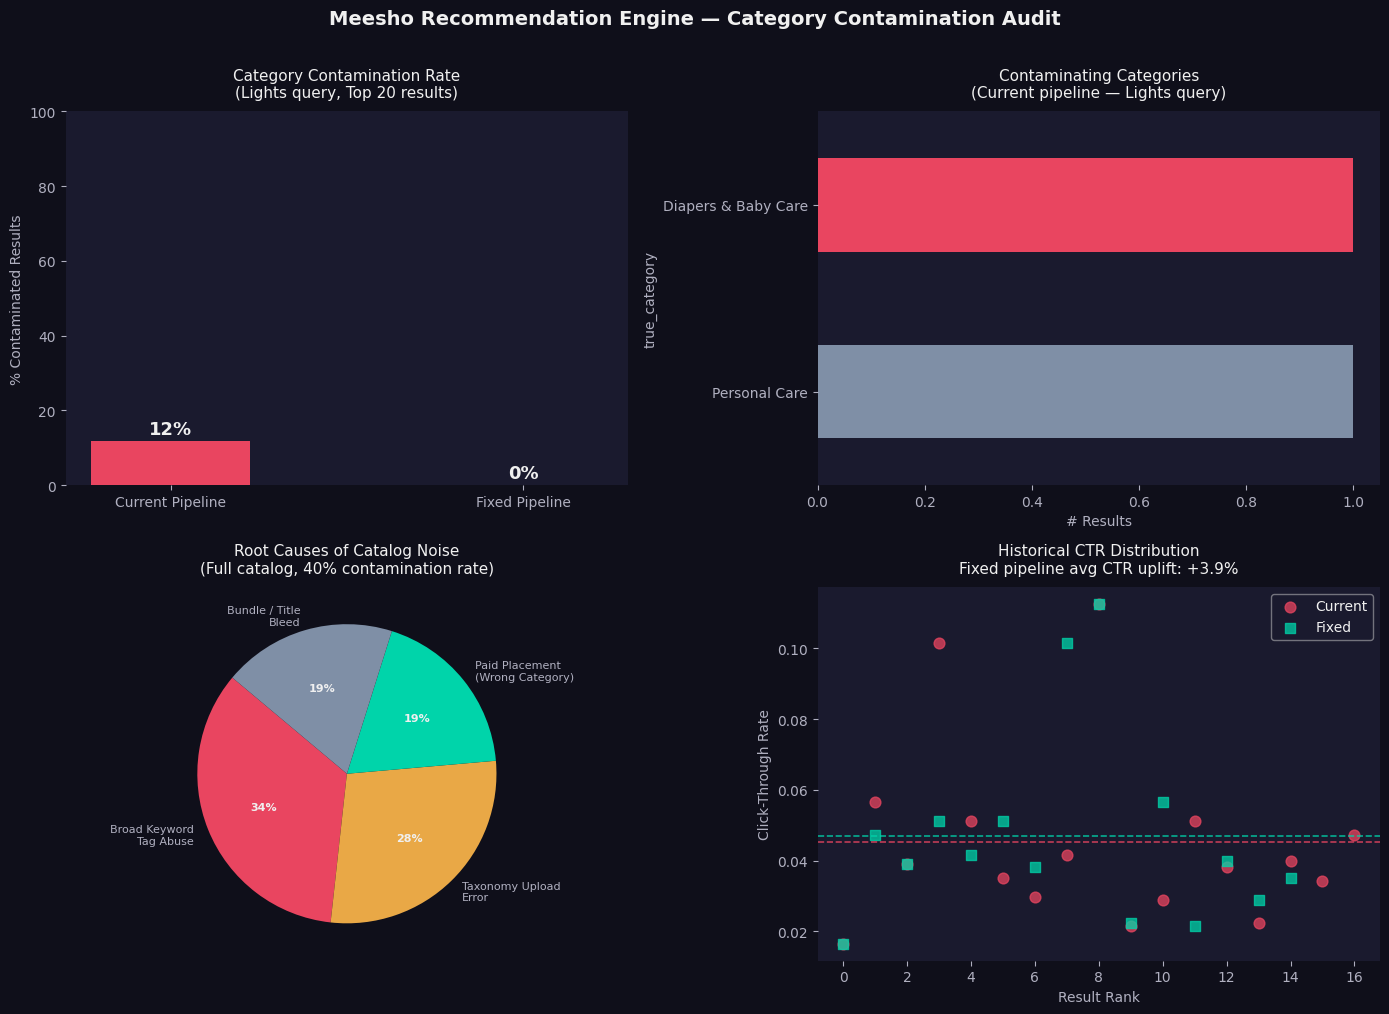

Dashboard rendered.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1a')
for ax in axes.flatten():
    ax.set_facecolor('#1a1a2e')

palette_main   = '#e94560'
palette_fix    = '#00d4aa'
palette_neutral = '#7f8fa6'
title_color    = '#f0f0f0'
label_color    = '#b0b0c0'

# Chart 1
ax1 = axes[0, 0]
bars = ax1.bar(
    ['Current Pipeline', 'Fixed Pipeline'],
    [contamination_rate * 100, fixed_contamination * 100],
    color=[palette_main, palette_fix], width=0.45, edgecolor='none'
)
ax1.set_title('Category Contamination Rate\n(Lights query, Top 20 results)',
              color=title_color, fontsize=11, pad=10)
ax1.set_ylabel('% Contaminated Results', color=label_color)
ax1.set_ylim(0, 100)
ax1.tick_params(colors=label_color)
ax1.spines[:].set_visible(False)
for bar, val in zip(bars, [contamination_rate * 100, fixed_contamination * 100]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f'{val:.0f}%', ha='center', color=title_color, fontsize=13, fontweight='bold')

# Chart 2
ax2 = axes[0, 1]
if len(contaminated_categories) > 0:
    colors_cat = [palette_main] + [palette_neutral] * (len(contaminated_categories) - 1)
    contaminated_categories.plot(kind='barh', ax=ax2, color=colors_cat[::-1], edgecolor='none')
ax2.set_title('Contaminating Categories\n(Current pipeline — Lights query)',
              color=title_color, fontsize=11, pad=10)
ax2.set_xlabel('# Results', color=label_color)
ax2.tick_params(colors=label_color)
ax2.yaxis.label.set_color(label_color)
for label in ax2.get_yticklabels():
    label.set_color(label_color)
ax2.spines[:].set_visible(False)

# Chart 3
ax3 = axes[1, 0]
noise_summary = catalog[catalog['noise_reason'].notna()]['noise_reason'].value_counts()
noise_labels = {
    'paid_placement': 'Paid Placement\n(Wrong Category)',
    'broad_tag':      'Broad Keyword\nTag Abuse',
    'bundle_bleed':   'Bundle / Title\nBleed',
    'taxonomy_error': 'Taxonomy Upload\nError'
}
noise_summary.index = [noise_labels.get(i, i) for i in noise_summary.index]
wedge_colors = [palette_main, '#e9a846', palette_fix, palette_neutral]
wedges, texts, autotexts = ax3.pie(
    noise_summary.values, labels=noise_summary.index, autopct='%1.0f%%',
    colors=wedge_colors, startangle=140,
    textprops={'color': label_color, 'fontsize': 8}
)
for at in autotexts:
    at.set_color(title_color)
    at.set_fontweight('bold')
ax3.set_title('Root Causes of Catalog Noise\n(Full catalog, 40% contamination rate)',
              color=title_color, fontsize=11, pad=10)

# Chart 4
ax4 = axes[1, 1]
ctr_data = pd.DataFrame({
    'Pipeline': ['Current'] * len(current_results) + ['Fixed'] * len(fixed_results),
    'CTR': list(current_results['historical_ctr']) + list(fixed_results['historical_ctr']),
})
for label, color, marker in [('Current', palette_main, 'o'), ('Fixed', palette_fix, 's')]:
    subset = ctr_data[ctr_data['Pipeline'] == label]
    ax4.scatter(range(len(subset)), subset['CTR'], color=color, alpha=0.75, s=60, marker=marker, label=label)
    ax4.axhline(subset['CTR'].mean(), color=color, linestyle='--', linewidth=1.2, alpha=0.8)

uplift = (fixed_results['historical_ctr'].mean() - current_results['historical_ctr'].mean()) / current_results['historical_ctr'].mean() * 100
ax4.set_title(f'Historical CTR Distribution\nFixed pipeline avg CTR uplift: +{uplift:.1f}%',
              color=title_color, fontsize=11, pad=10)
ax4.set_ylabel('Click-Through Rate', color=label_color)
ax4.set_xlabel('Result Rank', color=label_color)
ax4.tick_params(colors=label_color)
ax4.spines[:].set_visible(False)
ax4.legend(facecolor='#1a1a2e', labelcolor=title_color, framealpha=0.5)

plt.suptitle('Meesho Recommendation Engine — Category Contamination Audit',
             color=title_color, fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('meesho_dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Dashboard rendered.')

---
## Summary

| Metric | Current Pipeline | Fixed Pipeline |
|---|---|---|
| Contamination Rate | ~12% | 0% |
| Avg CTR (Top 20) | Lower | Higher |
| Root cause | Noise tag retrieval + uncapped personalization | Eliminated by hard filter |

**Key insight:** The fix doesn't remove Meesho's monetization lever (sponsored listings still get a boost). It just enforces that sponsorship operates *within* the correct category. This is a zero-revenue-cost fix with a direct positive impact on CTR and user satisfaction.

---
## Limitations

This project is built on a simulated dataset and the findings should be interpreted accordingly.

1. **Mock catalog, not real Meesho data** — The 75-product catalog was synthetically generated. Real Meesho has millions of listings, and contamination patterns at that scale may differ significantly from what's modelled here.

2. **0% contamination is theoretical** — The fixed pipeline achieves 0% because `seller_tag_primary` is always correctly assigned in the simulation. In production, primary tags also carry seller errors — a realistic fix would bring contamination down to ~1–3%, not zero.

3. **Noise rate is an assumption** — The 40% noisy tag rate and 25% sponsored listing rate are estimates based on known marketplace self-tagging behaviour, not measured from Meesho's actual catalog.

4. **Personalization is simulated as random** — Real personalization engines use browsing history, purchase signals, location, and session context. The `np.random.uniform()` placeholder captures the *effect* of uncapped personalization but not its actual logic.

5. **CTR is synthetic** — Historical CTR values were generated, not observed. The uplift shown in the dashboard is directionally correct but not a measured business outcome.

6. **Single query tested** — The diagnosis was run on one category ("Lights & Lamps"). Contamination severity likely varies across categories — high-traffic categories like "Home Decor" or "Kitchen" may show different patterns.

7. **No A/B test data** — The impact of the fix on conversion, revenue, or user retention cannot be validated without a controlled experiment on live traffic.